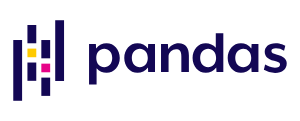





### In this tutorial we are going to work with Pandas. We will use Pandas to analyse two-dimensional data inclduing learning about data strutures, statistical analysis, and working with big and messy data.


From the Pandas docs:
    
    pandas is a Python package providing fast, flexible, and expressive data structures designed to make working with “relational” or “labeled” data both easy and intuitive. It aims to be the fundamental high-level building block for doing practical, real-world data analysis in Python. Additionally, it has the broader goal of becoming the most powerful and flexible open source data analysis/manipulation tool available in any language. It is already well on its way toward this goal.

We  `import` the module (in our environment) in the normal way.

It may be worth opening the other tutorial `002-H2-AMP-python_introduction` as a second tab so that you can refer to it.

In [1]:
import pandas as pd

## Creating datasets with Pandas

Pandas is based around **dataframes**.

**Dataframes** are two-dimensional, size-mutable, potentially heterogeneous tabular data, kind of like an excel document.

Data frames are indexed by column and row. 

We can create dataframes quiet easily. They can be a mix of numbers and strings

In [2]:
# create a data array
d = {'col1': [1, 2, 3, 4, 5],
     'col2': [10, 11,12,13,14]
    }

# convert to a data frome, called df
df = pd.DataFrame(data=d)

# show the data frame in a nice readable format
df


,col1,col2
0,1,10
1,2,11
2,3,12
3,4,13
4,5,14


### Numpy + Pandas

We can also use Numpy arrays in Pandas dataframes.

In [3]:
# need to import numpy
import numpy as np

# create a data array
d = {'col1': [1,2,3,4,5],
     'col2': np.array([1,2,3,4,5]),}

# convert to a data frome
df = pd.DataFrame(data=d)

# show the data frame
df


,col1,col2
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5


## Expanding and renaming: basics

now you have a `dataframe` you can re-model it to your own requirements.

In [4]:
# Lets rename some of the columns
df=df.rename(columns={"col1": "Index", "col2": "Radius"})

# and change the index to the number of radius's 
df=df.set_index('Index')

df

,Radius
Index,
1,1
2,2
3,3
4,4
5,5


### Adding new columns

In [8]:
# add new colum of area of a circle
df["circle_area"] = df["Radius"] * 1.882

np.pi*df.Radius**2

df

,Radius,circle_area
Index,,
1,1,1.882
2,2,3.764
3,3,5.646
4,4,7.528
5,5,9.410


&#x1F913;

***1.Make an dataframe with one column of numbers 1 to 50 with evenly spaced intervals of 0.1 and the second column of random numbers (radius) the same size.***

***2.Set the index to be the first column***

***3.Compute the area and volume of a circle and add as a third and fourth column.***

*HINT: Think back to the Numpy random and linspace functions*

## Stats with Pandas

We can perform lots of actions on the data such as calculating the mean

In [6]:
# the mean of the data
mean=df.mean()
print(mean)

Radius         3.000
circle_area    5.646
dtype: float64


When calcualting the mean,  it's better to specify the axis along which you want to perform the method

`axis=0` is mean of the columns, `axis=1` is mean of the rows

In [7]:
# the columnwise mean of the data
mean=df.mean(axis=0)
print(mean)

Radius         3.000
circle_area    5.646
dtype: float64


Pandas has a nice function for printing some descriptive statistics called `describe`

In [8]:
df.describe()

,Radius,circle_area
count,5.000000,5.000000
mean,3.000000,5.646000
std,1.581139,2.975703
min,1.000000,1.882000
25%,2.000000,3.764000
50%,3.000000,5.646000
75%,4.000000,7.528000
max,5.000000,9.410000


## 2. Plotting data with Pandas

Pandas plots data as well - and it's really easy

<Axes: xlabel='xdata'>

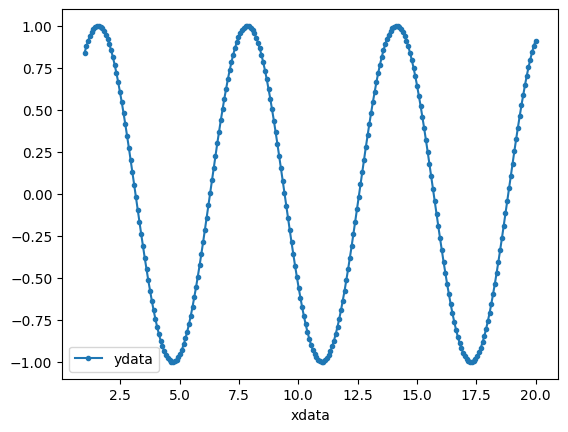

In [9]:
# create a data array
d = {'xdata': np.linspace(1,20,256),
     'ydata': np.sin(np.linspace(1,20,256))
    }

# convert to a data frome, called df
df = pd.DataFrame(data=d)

# tell Pandas what data we want to plot
df.plot(x='xdata',y='ydata',marker='.')

# simple!!!

&#x1F913;

***Add a third column containing the cosine of xdata and plot ydata and the new column on the same plot***

*HINT: You only use one plot function but include all yout ydata in a string array `e.g. y=['y1','y2','y3']`*

And remember you can see all your workspace variables by calling `whos` 

In [10]:
whos

Variable   Type         Data/Info
---------------------------------
d          dict         n=2
df         DataFrame             xdata     ydata\<...>n\n[256 rows x 2 columns]
mean       Series       Radius         3.000\ncir<...>    5.646\ndtype: float64
np         module       <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
pd         module       <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>


## 3. Reading data with Pandas

Reading data with Pandas is really easy. If we have an excel file, `pd.read_excel` can read those data directly into the workspace

I've added some oceanography data that we collected last year in a excel file called ***ocean_data.xlsx***

We usually call the dataframe `df` but you can call it anything you like.

We will let Pandas see if it can read the data without us telling it anything about the data. Its an `.xlxs` file so we need to use `read_excel` function


In [11]:
# try and read the data
od=pd.read_excel('data/ocean_profile.xlsx')

# use the head option to see the first five lines
od.head(5)


,Scan,DD,MMM,YYYY,HH:MM:SS,Pressure [db],Tv290C,Conductivity [mS/cm],"Fluorescence, WET Labs WETstar [mg/m^3]","PAR/Irradiance, Biospherical/Licor [umol photons/m^2/sec]","Oxygen, SBE 43 [umol/l]","Oxygen, SBE 43 [% saturation]","Depth [salt water, m], lat = 56","Salinity, Practical [PSU]","Density [sigma-theta, kg/m^3]","Sound Velocity [Chen-Millero, m/s]",Flag
0,299,12,Mar,2024,12:12:57,7,8.1566,34.596166,0.6666,32.899,245.914,82.748,6.936,33.1167,25.7721,1480.85,0
1,312,12,Mar,2024,12:13:01,8,8.1603,34.630028,0.6868,26.723,246.481,82.942,7.927,33.1487,25.7967,1480.92,0
2,324,12,Mar,2024,12:13:04,9,8.1594,34.666242,0.6557,21.144,246.435,82.928,8.918,33.1876,25.8273,1480.98,0
3,336,12,Mar,2024,12:13:07,10,8.1533,34.683565,0.6536,17.228,246.631,83.005,9.909,33.2113,25.8468,1481.00,0
4,348,12,Mar,2024,12:13:10,11,8.1542,34.691226,0.6500,13.990,246.154,82.878,10.899,33.2181,25.8521,1481.03,0


Looks pretty good. Let's say we aere just interested in the Fluoresence and PAR data and as the data are from a profile, we are only really interested in the change in these parameters with pressure or depth.

   Pres   Fluor     PAR
0     7  0.6666  32.899
1     8  0.6868  26.723
2     9  0.6557  21.144
3    10  0.6536  17.228
4    11  0.6500  13.990


array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

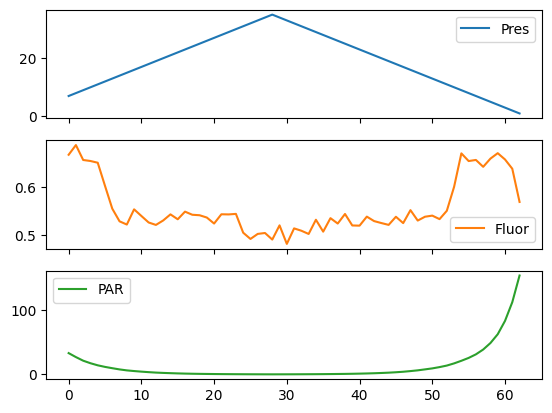

In [14]:
od=pd.read_excel('data/ocean_profile.xlsx',
                     names=["Pres","Fluor","PAR"], # tell pandas what to call our columns
                     usecols="F,I,J", # tell pandas which columns to use by listing column letters of numbers usecols=[1,2,3]
                )


# print the first 5 lines
print(od.head(5))

# plot the data
od.plot(subplots=True)

### Matplotlib is much better for plotting control

We need to import matplotlib so we can use the full library

In [15]:
import matplotlib.pyplot as plt

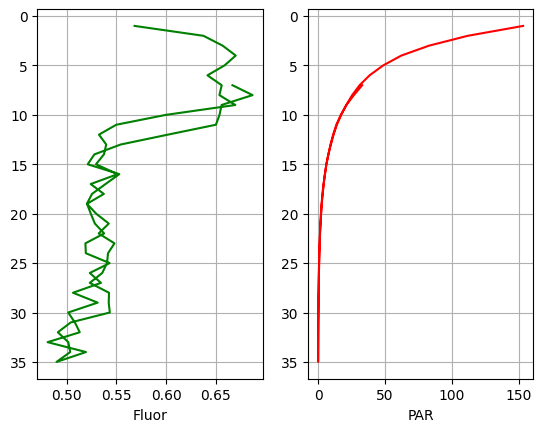

In [16]:
fig,ax =plt.subplots(1,2)

# first subplot
od.plot(ax=ax[0],
        x="Fluor",y="Pres",
        color='g',
        legend=False)

# second subplot
od.plot(ax=ax[1],
        x="PAR",y="Pres",
        color='r',
        legend=False)

# do some nice things to the data
for axes in ax:
    axes.invert_yaxis()
    axes.grid()

&#x1F913;

***Can you modify the read function above to read in temperature and salinity data, print the first 30 lines, and plot them against each other?***

## Big data and time series: a bit more complex

Pandas is really good at working with time series. We can even make them

We use `date_range` to make an array of dates

Lets make a dataframe that has `temperature`, `salinity`, and `pressure` to match the some dates

We'll pretent this is an instrument deployed at apporximately 750 m in the North Atlantic

We'll also extract some date vectors to do some analyis on.

In [17]:
# make a range of dates
dates = pd.date_range("20130101", # start date
                      periods=2000, # how many intervals
                      freq='12h') # frequency

dates

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 12:00:00',
               '2013-01-02 00:00:00', '2013-01-02 12:00:00',
               '2013-01-03 00:00:00', '2013-01-03 12:00:00',
               '2013-01-04 00:00:00', '2013-01-04 12:00:00',
               '2013-01-05 00:00:00', '2013-01-05 12:00:00',
               ...
               '2015-09-23 00:00:00', '2015-09-23 12:00:00',
               '2015-09-24 00:00:00', '2015-09-24 12:00:00',
               '2015-09-25 00:00:00', '2015-09-25 12:00:00',
               '2015-09-26 00:00:00', '2015-09-26 12:00:00',
               '2015-09-27 00:00:00', '2015-09-27 12:00:00'],
              dtype='datetime64[ns]', length=2000, freq='12h')

In [43]:
df = pd.DataFrame({'Year':dates.year,
                   'Month':dates.month,
                   'Day':dates.day,
                   'Temp':np.random.normal(4, scale=0.5,size=2000),
                    'Salinity':np.random.randn(2000)+35,
                    'Pressure':np.random.randn(2000)+750,},
                  index=dates, 
            )

df.tail(10)

,Year,Month,Day,Temp,Salinity,Pressure
2015-09-23 00:00:00,2015,9,23,4.119118,36.561229,751.135763
2015-09-23 12:00:00,2015,9,23,3.189986,36.218377,751.631947
2015-09-24 00:00:00,2015,9,24,4.071030,33.983544,749.217733
2015-09-24 12:00:00,2015,9,24,3.812373,35.379352,749.497606
2015-09-25 00:00:00,2015,9,25,3.484799,35.118629,751.780711
2015-09-25 12:00:00,2015,9,25,3.149994,35.291547,750.247701
2015-09-26 00:00:00,2015,9,26,4.370622,34.351564,750.305527
2015-09-26 12:00:00,2015,9,26,3.694781,36.231252,749.468039
2015-09-27 00:00:00,2015,9,27,4.036579,34.823830,749.647363
2015-09-27 12:00:00,2015,9,27,4.367195,34.302093,750.380841


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

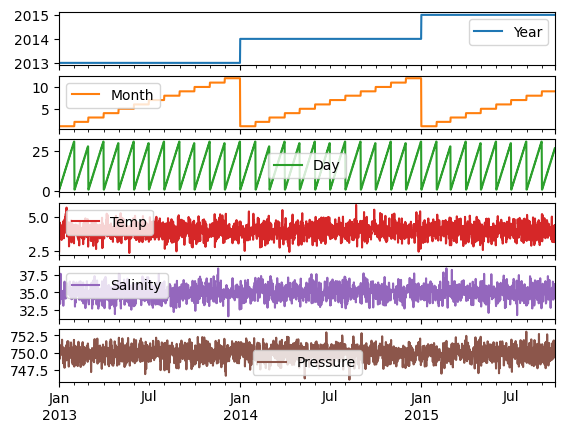

In [45]:
df.plot(subplots=True)

So we have around two years of data.

say we wanted to get the mean of each year

In [44]:
df.groupby(["Month"]).mean()

,Year,Day,Temp,Salinity,Pressure
Month,,,,,
1,2014.000000,16.000000,4.003370,35.048491,749.976581
2,2014.000000,14.500000,4.018877,35.089556,749.842946
3,2014.000000,16.000000,3.955043,35.064999,750.062506
4,2014.000000,15.500000,3.976891,35.035820,750.001871
5,2014.000000,16.000000,3.980814,35.013562,749.927957
6,2014.000000,15.500000,4.042073,34.987785,749.986433
7,2014.000000,16.000000,3.987578,35.005750,749.992682
8,2014.000000,16.000000,3.973595,34.861007,749.799220
9,2013.965517,15.034483,4.067744,35.055671,750.044084


I have added some time series data in the data folder. This time we have to use `read_csv` to read the data.

It is similar to `read_excel` but there a lot more options. 

I have written a read function with some comments. See if you can coplete the steps below:


&#x1F913;

***1.Rename the columns according to the header in the data file, and your intuition***

***2.Display the first 10 lines***

***3.Plot some data***

In [19]:
pd.read_csv('data/time_series.txt',
                sep='\s+', # seperator for > 1 space
                header=None, # no header data
                skiprows=1, # skip the first line as it is no -numeric
)

pd

<module 'pandas' from 'C:\\Users\\sa01ld\\AppData\\Roaming\\Python\\Python310\\site-packages\\pandas\\__init__.py'>

In [20]:
col_names = ["Year", "Month","Day", "Hour", "Temp","Cond","Pressure"]


pd.read_csv('data/time_series.txt',
                sep='\s+',
                header=None,
                skiprows=1,
           names=col_names,
           parse_dates={'time':['Year','Month','Day','Hour']}
)

C:\Users\sa01ld\AppData\Local\Temp\ipykernel_23308\2872768693.py:4: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  pd.read_csv('data/time_series.txt',
C:\Users\sa01ld\AppData\Local\Temp\ipykernel_23308\2872768693.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.read_csv('data/time_series.txt',


,time,Temp,Cond,Pressure
0,2022 07 16 12.00028,10.6942,39.1632,82.4
1,2022 07 16 12.50028,10.7513,39.2116,69.5
2,2022 07 16 13.00028,10.9088,39.3615,66.7
3,2022 07 16 13.50028,11.1099,39.5324,65.4
4,2022 07 16 14.00028,11.8191,40.1896,64.7
...,...,...,...,...
34784,2024 07 10 4.00056,12.2461,40.7165,62.7
34785,2024 07 10 4.50056,12.1026,40.5755,62.8
34786,2024 07 10 5.00056,12.0655,40.5082,63.1
34787,2024 07 10 5.50028,11.4653,40.0002,63.3


## Dunstaffnage weather record: more complex data

We are going to look at some data from a weather station here at Dunstaffnage. 

We can quite easily use inbuilt functions to read the data:

In [21]:
f = open('data/dunstaffnagedata.txt', 'r').readlines()[0:10]
f

['Dunstaffnage\n',
 'Location 188100E 734000N, Lat 56.451 Lon -5.439, 3m amsl\n',
 'Estimated data is marked with a * after the value.\n',
 'Missing data (more than 2 days missing in month) is marked by  ---.\n',
 'Sunshine data taken from an automatic Kipp & Zonen sensor marked with a #, otherwise sunshine data taken from a Campbell Stokes recorder.\n',
 '   yyyy  mm   tmax    tmin      af    rain     sun\n',
 '              degC    degC    days      mm   hours\n',
 '   1971   6   ---     ---     ---     71.4    ---\n',
 '   1971   7   ---     ---     ---     50.1    ---\n',
 '   1971   8   ---     ---     ---     83.0    ---\n']

While we can see the data, we can't do any analysis in this format. 

This time we will `use pd.read_csv()` to read in our data. This fucntion reads pretty much any text or delimited data file

In [22]:
df=pd.read_csv('data/dunstaffnagedata.txt')
print(df)

                                                                                                      Dunstaffnage
Location 188100E 734000N                           Lat 56.451 Lon -5.439                                   3m amsl
Estimated data is marked with a * after the value. NaN                                                         NaN
Missing data (more than 2 days missing in month... NaN                                                         NaN
Sunshine data taken from an automatic Kipp & Zo... otherwise sunshine data taken from a Campbell S...          NaN
   yyyy  mm   tmax    tmin      af    rain     sun NaN                                                         NaN
...                                                                                                            ...
   2024   2    8.8     4.3       3   204.4    ---  NaN                                                         NaN
   2024   3   10.2     4.6       0    86.6    ---  NaN                          

The data are being read but only one column, when we are expecting seven.

We need to pass a few **arguments**. These are inputs to a function that tell the function how to operate. We can either open the file by double clicking it, or we can look at the output from the first attempt using the builtin `open` function in our first code cell.

First, we need to skip a few rows. If we count down from the top of the data file there are seven non-numeric rows. So we can pass `skiprows=7`

We have skipped all the non-numeric data, including the column names, so we need to rename them. There are seven columns. Let's make an array of new names

In [23]:
col_names = ["Year", "Month", "tmax", "tmin","af","rain","sunhours"]

Now we use `names=col_names` to tell the function where to get the names from.

In [24]:
df = pd.read_csv('data/dunstaffnagedata.txt',
                 skiprows=7,
                 names=col_names,
                 sep='\s+',
                 na_values='---',\
                 index_col='time',
                 parse_dates={'time':['Year','Month']})

C:\Users\sa01ld\AppData\Local\Temp\ipykernel_23308\787458594.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('data/dunstaffnagedata.txt',
C:\Users\sa01ld\AppData\Local\Temp\ipykernel_23308\787458594.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('data/dunstaffnagedata.txt',


#### Print first 5 lines of dataset

In [25]:
df.head() 

,tmax,tmin,af,rain,sunhours
time,,,,,
1971-06-01,NaN,NaN,NaN,71.4,NaN
1971-07-01,NaN,NaN,NaN,50.1,NaN
1971-08-01,NaN,NaN,NaN,83.0,NaN
1971-09-01,NaN,NaN,NaN,75.3,NaN
1971-10-01,NaN,NaN,NaN,270.7,NaN


#### Print last 5 lines of dataset

In [26]:
df.tail() 

,tmax,tmin,af,rain,sunhours
time,,,,,
2024-02-01,8.8,4.3,3.0,204.4,NaN
2024-03-01,10.2,4.6,0.0,86.6,NaN
2024-04-01,12.5,5.4,0.0,117.4,NaN
2024-05-01,17.9,10.2,0.0,49.6,NaN
2024-06-01,16.2,9.3,0.0,108.8,NaN


#### Print data single timestep

We can do this by indexing the time column, which we designateed as an index when we read the data in:

    index_col='time'
    
The orginal data had two date-like columns **year** and **month**. We use a Pandas in-built parser to convert this to datetime data. 

    parse_dates={'time':['Year','Month']}
    
**Note:** The high level functions of each module such as `read_csv` in Pandas have very clear documentaion and exmaples. See [here](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).

In [27]:
df.loc['2022-10-01'] 

tmax         14.3
tmin          9.6
af            0.0
rain        240.4
sunhours      NaN
Name: 2022-10-01 00:00:00, dtype: float64

#### Show data for single variable

In [28]:
df.rain

time
1971-06-01     71.4
1971-07-01     50.1
1971-08-01     83.0
1971-09-01     75.3
1971-10-01    270.7
              ...  
2024-02-01    204.4
2024-03-01     86.6
2024-04-01    117.4
2024-05-01     49.6
2024-06-01    108.8
Name: rain, Length: 637, dtype: float64

#### Quick plot

Pandas has lots of inbuilt functionality for plotting variables from the dataframe. For example, we can run some of these in the code block below.We can use pandas to quickly plot all the variables in the dataframe to get an overview of the data.

array([[<Axes: xlabel='time'>, <Axes: xlabel='time'>,
        <Axes: xlabel='time'>, <Axes: xlabel='time'>],
       [<Axes: xlabel='time'>, <Axes: xlabel='time'>,
        <Axes: xlabel='time'>, <Axes: xlabel='time'>]], dtype=object)

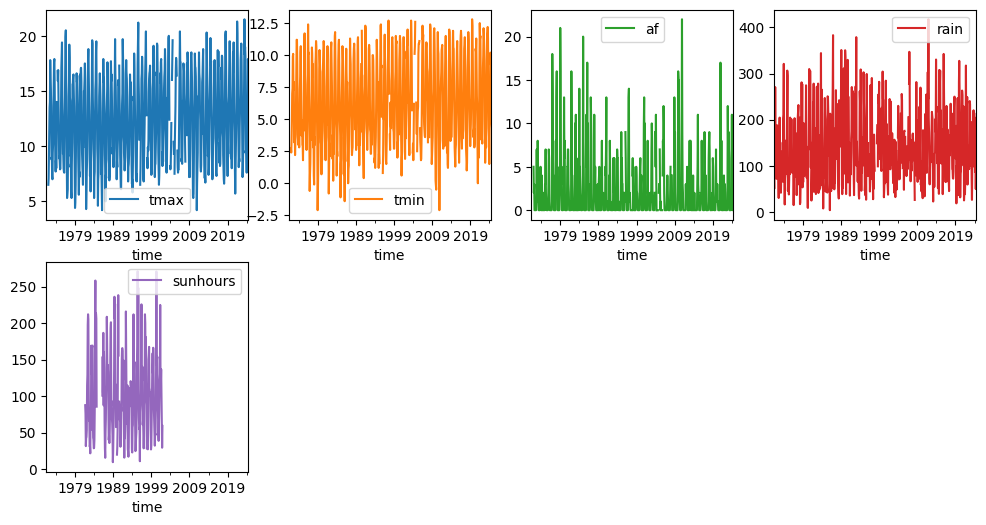

In [29]:
df.plot(subplots=True, layout=(2, 4), figsize=(12, 6), sharex=False)

#### Plot single variable

<Axes: xlabel='time', ylabel='Rain (mm)'>

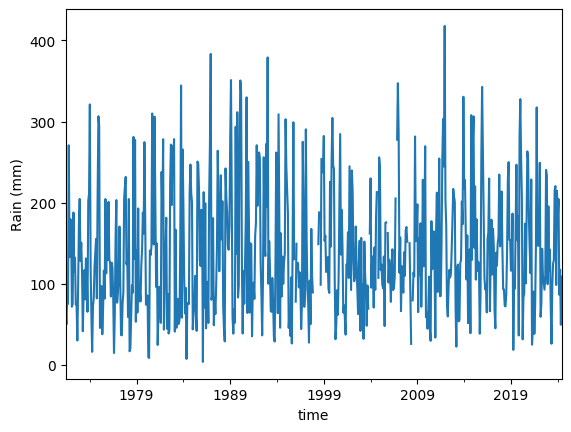

In [30]:
df.rain.plot(ylabel="Rain (mm)")

#### Plot multiple variables

<Axes: xlabel='time', ylabel='Temperature [degC]'>

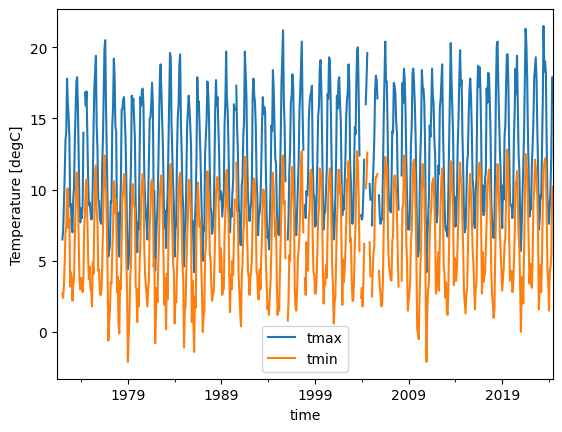

In [31]:
columns = ["tmax", "tmin"]
df[columns].plot(ylabel="Temperature [degC]")


In [32]:
df.rain

time
1971-06-01     71.4
1971-07-01     50.1
1971-08-01     83.0
1971-09-01     75.3
1971-10-01    270.7
              ...  
2024-02-01    204.4
2024-03-01     86.6
2024-04-01    117.4
2024-05-01     49.6
2024-06-01    108.8
Name: rain, Length: 637, dtype: float64

#### Plot subset of years

<Axes: xlabel='time', ylabel='Temperature [degC]'>

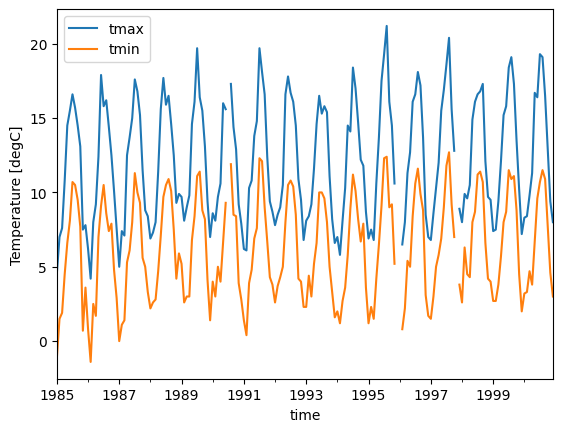

In [33]:
df[columns]['1985':'2000'].plot(ylabel="Temperature [degC]")

That was pretty simple, and we are only using Pandas, but if we want to make any nicer plots, we will have to use Matplotlib. We wil also import numpy as we will want to use someof its fucntions as well.

#### Sub-set high precipitation months

In [34]:
import matplotlib.pyplot as plt
import numpy as np

Text(0, 0.5, 'Precipitation [mm/month]')

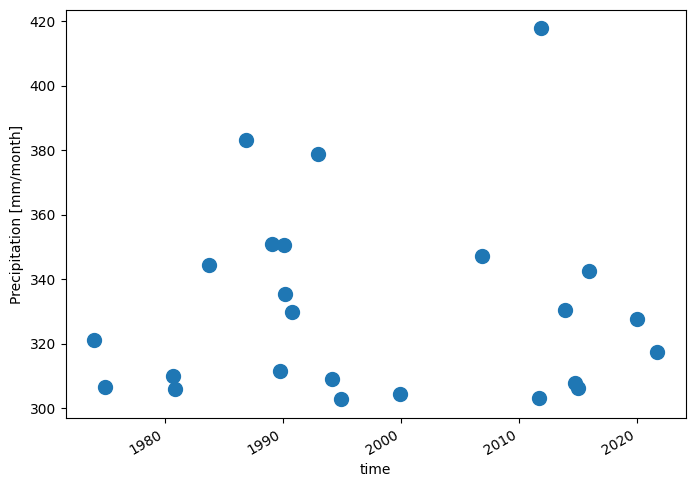

In [35]:
plt.figure(figsize=(8,6))
df[df.rain>300].rain.plot(style='o',ms=10)
plt.ylabel('Precipitation [mm/month]')

#### Create a monthly precipitation climatology

First we take an index of the months. 

In [36]:
IMonth=df.index.month
rain_mm = df.groupby(IMonth)['rain'].mean() 

In [40]:
IMonth

Index([ 6,  7,  8,  9, 10, 11, 12,  1,  2,  3,
       ...
        9, 10, 11, 12,  1,  2,  3,  4,  5,  6],
      dtype='int32', name='time', length=637)

You can type `Imonth` or `print(IMonth)`. If you want to see the results

Text(0.5, 1.0, 'Cumulative monthly precipitation climatology: 1971-2024')

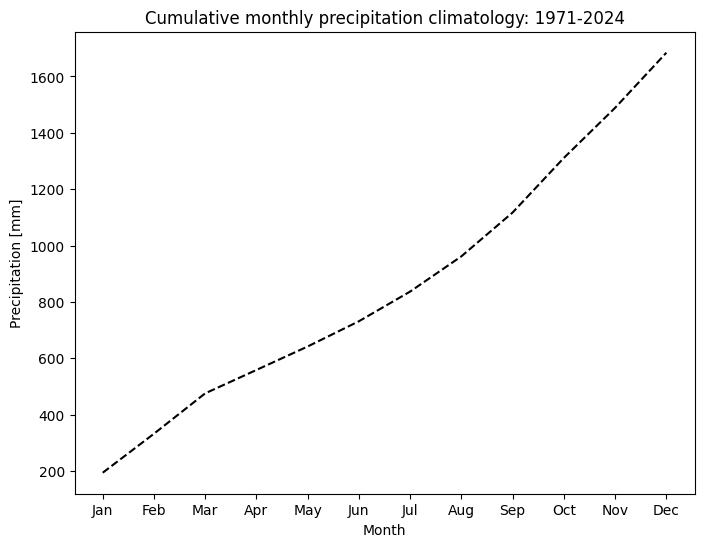

In [37]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(rain_mm.cumsum(),'k--')
ax.set_ylabel('Precipitation [mm]')
ax.set_xlabel('Month')
ticklabels = df.loc['2000'].index.strftime('%b')
ax.set_xticks(np.arange(1,13))
ax.set_xticklabels(ticklabels) # add monthlabels to the xaxis
ax.set_title('Cumulative monthly precipitation climatology: {}-{}'.format(df.index.year[0],df.index.year[-1]))

Now lets do some data processing and analysis.

Below we will average the existing tmax and tmin variables to give an estimate of the monthly average temperature (***Disclaimer:*** this probably isn't a very good estimate for average monthly temperature!). We will then interpolate missing values and apply a 12 month moving average before plotting. Finally, we will plot the monthly temperature climatology over the whole record.

In [ ]:
# Average tmax and tmin columns to give monthly average temperature (tavg)
columns = ["tmax", "tmin"]
df['tavg'] = df[columns].mean(axis=1)

#### Plot 12-month rolling averaged min, max and average temperatures

In [ ]:
# set figure dimensions
plt.figure(figsize=(8,6))

# apply statistcs 
df['tavg'].interpolate().rolling(window=12).mean().plot(color='k')
df['tmax'].interpolate().rolling(window=12).mean().plot(color='r')
df['tmin'].interpolate().rolling(window=12).mean().plot(color='b')

# add a legend
plt.legend(['Average Temp','Max Temp','Min Temp'],frameon=False,loc='best')

# add a y-label
plt.ylabel('Temperature [degC]')

# add a title
plt.title('12-month rolling averaged temperatures')

#### Average by month to produce monthly climatology

In [ ]:
tavg_mm=df.groupby(df.index.month)['tavg'].mean()

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(tavg_mm,'b')
ax.set_ylabel('Temperature [degC]')
ax.set_xlabel('Month')

# add a grid 
plt.grid()

# set title 
ax.set_title('Monthly temperature climatology: {}-{}'.format(df.index.year[0],df.index.year[-1]))

# set tick labels
ticklabels = df.loc['2000'].index.strftime('%b') # add month xtick labels
ax.set_xticks(np.arange(1,13))
ax.set_xticklabels(ticklabels) #add monthlabels to the xaxis

# Linear Regression

Now for some statistics. Here we apply a linear regression on time and average temperature to calculate the warming trend at Dunstaffnage during the record.

##### Interpolate missing values, apply 12 month moving average and remove NaN's

In [ ]:
tavg=df['tavg'].interpolate().rolling(window=12).mean().dropna()

Compute days since the first date in the index and convert this to decades for the time variable

In [ ]:
delta = (tavg.index - tavg.index[0])
days = delta.days
decades = days/365/10 # convert to decades so we get the slope estimate in temperature change per decade

x = decades
y = tavg.values

#### The regression

We'll need `stats` from the SciPy module for this.

In [ ]:
from scipy import stats

To get help on a function you can type it's name followed by '?' to print the functions docstring. 
Adding '??' to the end of the function name will print the raw python code so you can look in detail what the function is doing 'under the hood'

    stats.linregress??

In [ ]:
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
print("slope: %f, intercept: %f" % (slope, intercept))
print("R-squared: %f" % r_value**2)

# Plot the data with a trend line
plt.figure(figsize=(15, 5))
plt.plot(df.index[0]+delta, y, 'o', label='original data')
plt.plot(df.index[0]+delta, intercept + slope*x, 'r', label='fitted line')
plt.legend()
plt.grid()
plt.show()

# print the regression after the figure
print('Temperature trend at Dunstaffnage is {} degrees per decade'.format(round(slope,2)))

As an example of signal processing using SciPy, we will calculate the discrete Fourier transform on our average temperature data using the SciPy FFTpack module.

In [ ]:
import scipy as sp
import scipy.fftpack
import datetime

# first clean the data by interpolating missing points and removing any remaining NaN's
data = df['tavg'].interpolate().dropna() 

#print(data.values) # sometimes need to extract data from a structure using .values
#print(data)

temp_fft = sp.fftpack.fft(data.values) # Return discrete Fourier transform

temp_psd = np.abs(temp_fft) ** 2

fftfreq = sp.fftpack.fftfreq(len(temp_psd), 1. / 12) # sample frequencies for monthly data

i = fftfreq > 0

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(fftfreq[i], 10 * np.log10(temp_psd[i]))
ax.set_xlim(0, 5)
ax.set_xlabel('Frequency (1/year)')
ax.set_ylabel('PSD (dB)')

Because the fundamental frequency of the signal is the yearly variation of the temperature (the seasonal cycle), we observe a clear peak at f=1 cycle/year. 

We can cut out frequencies higher than the fundamental frequency and perform an inverse FFT to convert the modified Fourier transform back to the temporal domain. This way, we recover a smoothed version of the signal (because the fast variations have been lost when we removed the high frequencies in the Fourier transform) that mainly contains the fundamental frequency, as shown in the following figure:

In [ ]:
temp_fft_bis = temp_fft.copy()
temp_fft_bis[np.abs(fftfreq) > 1.1] = 0

temp_slow = np.real(sp.fftpack.ifft(temp_fft_bis))

fig, ax = plt.subplots(figsize=(6, 3))
#data.plot(ax=ax,color='b',lw=1.0, label='Original signal')
ax.plot(data, color='b', linewidth=1.0)
ax.plot(data.index,temp_slow, 'Orange', '-')
ax.set_xlim(datetime.date(1994, 1, 1),datetime.date(2000, 1, 1))
ax.legend(['Original signal','Filtered signal'])
ax.set_xlabel('Date')
ax.set_ylabel('Mean temperature')
#plt.show()

# Correlation

Lets finish by calculating some comparison statistics from the dataset. We will first plot the correlation matrix across all variables in the dataframe using Pandas inbuilt pairwise correlation of columns function. This exploratory data analysis will inform how we then progress with analysing the data in detail.

In [ ]:
# Print correlation matrix across all variables in dataframe

print('Correlation matrix: \n{}'.format(df.corr))

We see that there is a relativly strong negative correlation of -0.64 between sunlight hours and rainfall (as you might expect!). 

We can dig into this relationship a little deeper using NumPy and SciPy to calculate the comparison statistics and fit a linear regression to compare the observed monthly sunlight hours with the monthly rainfall total for the decade 1987-1997.

#### Extract and clean sunhours and rain between 1987 and 1997

In [ ]:
columns=['sunhours','rain']
data=df[columns]['1987':'1997'].interpolate().dropna() 

plt.scatter(data['sunhours'].values,data['rain'].values)
plt.xlabel('Hours of Sunshine per month')
plt.ylabel('Precipitation [mm/month]')

#### Compare the correlations calculated by NumPy and SciPy methods

In [ ]:
# get raw data arrays
x = data['sunhours'].values
y = data['rain'].values 

r = np.corrcoef(x, y) # NumPy correlation coefficient
print('NumPy Corelation coefficient = {}'.format(r[0, 1]))

r = stats.pearsonr(x, y) # SciPy Pearson correlation coefficient and p-value. See 'stats.pearsonr?' for more detail
print('SciPy Pearson R = {}'.format(r[0])) 

#### Print linear regression results

In [ ]:
result = stats.linregress(x, y)
print('Regression slope = {}'.format(result.slope))
print('Regression intercept = {}'.format(result.intercept))
print('Regression pvalue = {}'.format(result.pvalue))
print('Regression standard error = {}'.format(result.stderr))
print('Regression R^2 = {}'.format(result.rvalue**2))

From this comparison it seems reasonable to assume that months with more sunlight hours will have less rainfall; looking at the R^2 value, 35% of the variance in rainfall can be explained by variability in sunlight. We will now take this a little further and see if we can predict rainfall from sunlight hours by fitting a linear regression model from the scikit-learn module.

# Scikit-learn

Scikit-learn (or sklearn) is a powerful module designed for machine learning in Python. Sklearn is built on NumPy, SciPy, and matplotlib and provides simple and efficient tools for predictive data analysis. Below we will fit a linear model to the data (similar to what we did above using SciPy) but then use it to make predictions.

In [ ]:
from sklearn.linear_model import LinearRegression

X = x[:, np.newaxis] # Use only one feature

reg = LinearRegression().fit(X, y) # Sanity check: The values below should look very similar to the values calculated using the SciPy stats.linregress method above.
print('Regression R^2 = {}'.format(reg.score(X, y)))
print('Regression slope: {}'.format(reg.coef_[0]))
print('Regression intercept: {}'.format(reg.intercept_))

Notice that the slope and intercept are nearly identical to the values calculated using the SciPy method (good news!). We can now divide the data into a training and test set and use scikit-learn to fit a linear model to the training set and use the test set to assess the accuracy of the predictions (and, finally, make a prediction of monthly precipitation from sunlight hours).

#### Write a predictive regression model 

In [ ]:
from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error, r2_score

X = x[:, np.newaxis] # Use only one feature

#### Splitting the datasets into training and testing sets (you could do this manually, i.e. X_train = X[:-20])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, train_size=0.3)

# Create linear regression object
model = LinearRegression()

# Train the model using the training sets
model.fit(X_train, y_train)

# Make predictions using the testing set
y_pred = model.predict(X_test)

# Plot outputs
plt.scatter(X_test, y_test, color="black", label='observations')
plt.plot(X_test, y_pred, color="blue", linewidth=3, label='prediction')
plt.xlabel('Sunlight hours per month')
plt.ylabel('Precipitation [mm/month]')
plt.legend()
#plt.show()

# Running Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
rmse = mean_squared_error(y_test, predictions, squared=False)

print('The r^2 is: ', r2)
print('The RMSE is: ', rmse)

#### Make a prediction

In [ ]:
monthly_sunhours = 100
prediction = model.predict(np.array([[monthly_sunhours]]))[0]
print('For a month with {} hours of sunlight, I would predict there to be {} mm of rain'.format(int(monthly_sunhours),np.round(prediction,2)))